## RunPod Setup Guide

This notebook is designed to run on [RunPod](https://www.runpod.io/) GPU pods. Follow the
steps below to get a working environment.

### 1. Choose a GPU

Pick a GPU based on which Qwen3-VL model you plan to run:

| Model | Min VRAM | Recommended RunPod GPU | On-Demand Price |
|-------|----------|------------------------|-----------------|
| **Qwen3-VL-2B** | ~5 GB | RTX A5000 (24 GB) | ~$0.16/hr |
| **Qwen3-VL-4B** | ~10 GB | RTX A5000 (24 GB) | ~$0.16/hr |
| **Qwen3-VL-8B** (FP16) | ~18 GB | RTX A6000 (48 GB) | ~$0.33/hr |
| **Qwen3-VL-8B** (FP8) | ~8 GB | RTX 4090 (24 GB) | ~$0.34/hr |
| **Qwen3-VL-32B** (FP16) | ~64 GB | A100 SXM (80 GB) | ~$1.39/hr |
| **Qwen3-VL-32B** (FP8) | ~20 GB | RTX A6000 (48 GB) | ~$0.33/hr |

> **Budget tip:** For prototyping with the 2B model, any 24 GB GPU works. The cheapest
> options are RTX A5000 ($0.16/hr) or RTX 3090 ($0.22/hr). For production-quality extraction
> with the 8B model, an RTX A6000 or A40 (both 48 GB, ~$0.33-0.35/hr) gives comfortable
> headroom for KV-cache.

### 2. Choose a Template

When creating your pod, select the **PyTorch** template:

- **Template:** `RunPod PyTorch 2.8.0` (CUDA 12.8 pre-installed)
- This gives you: Python 3.11+, PyTorch 2.8, CUDA 12.8, cuDNN, JupyterLab on port 8888

> **Why PyTorch and not plain CUDA?** vLLM ships its own CUDA kernels but depends on
> PyTorch for tensor operations. The PyTorch template has the correct CUDA toolkit, driver
> versions, and `torch` pre-installed so `pip install vllm` can link against them without
> version conflicts. The plain CUDA template would require you to install PyTorch manually
> and match versions yourself.

### 3. System Dependencies (apt)

Run the cell below **once** after pod startup to install required system packages.
These are needed by `pdf2image` (Poppler) and DOCX conversion (LibreOffice).

### 4. Python Dependencies (pip)

The second cell installs all Python packages with **pinned versions** that are tested to
work together. vLLM bundles its own PyTorch/CUDA wheels, so version alignment is critical.

In [1]:
# ── System dependencies (run once after pod startup) ──────────────
# poppler-utils  — required by pdf2image (provides pdftoppm binary)
# libreoffice    — required for DOCX-to-PDF conversion (headless mode)
# libgl1, libglib2.0-0 — image processing runtime deps
!apt-get update -qq && apt-get install -y -qq \
    poppler-utils \
    libreoffice \
    libgl1 \
    libglib2.0-0 \
    && echo "System packages installed successfully"

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
debconf: delaying package configuration, since apt-utils is not installed
Selecting previously unselected package poppler-data.
(Reading database ... 49062 files and directories currently installed.)
Preparing to unpack .../00-poppler-data_0.4.12-1_all.deb ...
Unpacking poppler-data (0.4.12-1) ...
Selecting previously unselected package libreoffice-style-colibre.
Preparing to unpack .../01-libreoffice-style-colibre_4%3a24.2.7-0ubuntu0.24.04.4_all.deb ...
Unpacking libreoffice-style-colibre (4:24.2.7-0ubuntu0.24.04.4) ...
Selecting previously unselected package libreoffice-uiconfig-common.
Preparing to unpack .../02-libreoffice-uiconfig-common_4%3a24.2.7-0ubuntu0.24.04.4_all.deb ...
Unpacking libreoffice-uiconfig-common (4:24.2.7-0ubuntu0.24.04.4) ...
Selecting previously unsele

In [2]:
# ── Python dependencies (pinned versions, tested on RunPod PyTorch 2.8 / CUDA 12.8) ──
# vLLM >= 0.11.0 is required for Qwen3-VL support (added in v0.11.0, Oct 2025).
# httpx is used for HTTP requests to the vLLM server (matches production codebase).
!pip install \
    "vllm>=0.11.0" \
    "httpx>=0.27.0" \
    "qwen-vl-utils==0.0.14" \
    "Pillow>=10.4.0,<13.0" \
    "pdf2image==1.17.0" \
    "tqdm>=4.66.0" \
    "ipywidgets>=8.1.0" \
    "hf_transfer" \
    "opik"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.3/508.3 MB 107.9 MB/s  0:00:030:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 79.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 58.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 48.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 72.2 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 95.4 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.7/124.7 MB 112.7 MB/s  0:00:010:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 25.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 59.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.5/170.5 MB 116.3 MB/s  0:00:010:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.9/34.9 MB 105.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 33.4 MB/s  0:00:00
   ━━━━━━━━━

In [3]:
# ── Verify environment ─────────────────────────────────────────────
import importlib.metadata
import subprocess
import torch

print(f"Python:  {subprocess.check_output(['python3', '--version']).decode().strip()}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA:    {torch.version.cuda}")
print(f"GPU:     {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NOT AVAILABLE'}")
print(f"VRAM:    {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB" if torch.cuda.is_available() else "")

import httpx
import vllm
import PIL
print(f"vLLM:    {vllm.__version__}")
print(f"httpx:   {httpx.__version__}")
print(f"Pillow:  {PIL.__version__}")
print(f"pdf2image: {importlib.metadata.version('pdf2image')}")

Python:  Python 3.12.3
PyTorch: 2.9.1+cu128
CUDA:    12.8
GPU:     NVIDIA A100-SXM4-80GB
VRAM:    85.0 GB
vLLM:    0.16.0
httpx:   0.28.1
Pillow:  11.0.0
pdf2image: 1.17.0


# Qwen3-VL Document Extraction via vLLM Server

This notebook demonstrates how to use **Qwen3-VL-8B-Instruct** served via a **vLLM HTTP
server** (`/v1/chat/completions` API) to extract structured content from document images:

1. **Content extraction** â€” full page text as Markdown with tables rendered as inline HTML
   `<table>` blocks (no duplication between text and tables)
2. **Figure/diagram extraction** â€” page image saved with a detailed description (summary of what is seen)

Each page gets **2 model calls** (content + figures). Text and table extraction are unified
into a single prompt to avoid overlap â€” the model sees the page once and outputs each element
exactly once.

Supported input formats: **JPG/PNG** images, **PDF** documents, **DOCX** documents.

### vLLM Server vs Offline Inference

This notebook uses **vLLM as an HTTP server**, which mirrors the production architecture
in `vision-rag/docker-compose.yml` where Qwen3-VL runs as a standalone container
exposing `/v1/chat/completions`.

| Aspect | Offline (vllm.LLM) | vLLM Server (this notebook) |
|--------|-----------------------------|-------------------------------|
| Model loading | `vllm.LLM()` in-process | vLLM server handles it |
| API | Direct Python calls | OpenAI-compatible REST API |
| Batch processing | `llm.chat()` with list | vLLM continuous batching + PagedAttention |
| Input format | Python dicts | JSON over HTTP |
| Scaling | Single GPU, single process | Horizontal across GPUs/nodes |
| Use case | Development, experimentation | Production, high throughput |

### Prerequisites

- **GPU**: NVIDIA GPU with â‰¥ 24 GB VRAM (RTX A5000 or better)
- For PDF support: `poppler-utils` system package (`sudo apt install poppler-utils`)
- For DOCX support: `libreoffice` system package (`sudo apt install libreoffice`)

## Choosing a Qwen3-VL Model

The [Qwen3-VL collection](https://huggingface.co/collections/Qwen/qwen3-vl) offers six model
sizes — each available as **Instruct** (direct answers, faster) and **Thinking** (chain-of-thought
reasoning, higher quality on complex tasks). There are also FP8 and GGUF quantised variants
for reduced memory footprint.

### Available Models

| Model ID | Params | Architecture | VRAM (BF16) | VRAM (FP8) | Best for |
|----------|--------|-------------|-------------|------------|----------|
| `Qwen3-VL-2B-Instruct` | 2B | Dense | ~4-5 GB | ~3 GB | Edge / laptop; quick prototyping |
| `Qwen3-VL-4B-Instruct` | 4B | Dense | ~8-10 GB | ~5 GB | Consumer GPU (RTX 3060/4060) |
| `Qwen3-VL-8B-Instruct` | 8.77B | Dense | 16-18 GB | 6-8 GB | **Best cost-performance ratio** for document extraction |
| `Qwen3-VL-30B-A3B-Instruct` | 30B (3B active) | MoE | ~10-12 GB | ~7 GB | MoE efficiency; only 3B active params per token |
| `Qwen3-VL-32B-Instruct` | 32B | Dense | ~64 GB | ~20 GB | High-quality extraction; needs A100/H100 |
| `Qwen3-VL-235B-A22B-Instruct` | 235B (22B active) | MoE | multi-GPU | multi-GPU | State-of-the-art quality; production at scale |

> Replace `-Instruct` with `-Thinking` for the reasoning variant (adds chain-of-thought;
> better on math/STEM but slower and more tokens).

### Document Extraction Benchmarks

Scores sourced from official Qwen evaluations and community benchmarks:

| Model | DocVQA | OCRBench | MMMU | Inference Speed |
|-------|--------|----------|------|-----------------|
| Qwen3-VL-2B | ~88% | ~780 | ~52 | Fastest |
| Qwen3-VL-4B | ~92% | ~840 | ~58 | Fast |
| **Qwen3-VL-8B** | **~96%** | **896** | **69-70** | 45-60 tok/s |
| Qwen3-VL-32B | ~97% | 910 | ~74 | 15-25 tok/s |
| Qwen3-VL-235B | 97%+ | 920+ | — | Requires multi-GPU |

### Recommendations for This Notebook

- **Start with `Qwen3-VL-2B-Instruct`** (the default below) — it loads fast, needs minimal
  VRAM, and is good enough to validate your pipeline and prompts. If quality is insufficient,
  scale up.
- **`Qwen3-VL-8B-Instruct`** is the sweet spot for production document extraction. It scores
  96% on DocVQA and 896 on OCRBench while fitting on a single 24 GB GPU in FP8 or a single
  A100 in BF16. This is the model used in the vision-rag production pipeline.
- **`Qwen3-VL-32B-Instruct`** gives a small quality bump (~1% DocVQA, +14 OCRBench) but
  requires ~64 GB VRAM in BF16 — practical only on A100 80GB or with FP8 quantisation.
- **`Qwen3-VL-4B-Instruct`** is a middle ground if 2B quality is too low but 8B doesn't fit
  your GPU.
- **Thinking variants** (`-Thinking`) are worth testing for complex tables or diagrams where
  the model needs to reason about layout, but expect 2-3x more output tokens and slower
  inference.
- **MoE models** (`30B-A3B`, `235B-A22B`) use mixture-of-experts: large total parameters but
  only a fraction is active per token. They need more disk/download but less compute per query.

To switch models, change `MODEL_ID` in the configuration cell below.

### Imports and Configuration

Standard library imports plus PIL for image handling and tqdm for progress bars.

Configuration is split into three groups:
- **Model** — which Qwen3-VL checkpoint to load and the random seed for reproducibility.
- **Sampling** — generation hyper-parameters (`max_tokens`, `temperature`, `top_p`, `top_k`).
  Low temperature (0.1) keeps extraction deterministic; raise it for more creative descriptions.
- **Document processing** — DPI for PDF rasterization and the output directory for saved figures.

In [4]:
import base64
import io
import json
import subprocess
import tempfile
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime
from pathlib import Path

import httpx
from IPython.display import display, HTML, Image as IPImage, Markdown
from PIL import Image
from tqdm.notebook import tqdm

# ── Server Configuration ───────────────────────────────────────────
VLLM_BASE_URL = "http://localhost:8002"    # vLLM server address
MODEL_ID = "Qwen/Qwen3-VL-8B-Instruct"
REQUEST_TIMEOUT = 180.0                     # seconds per HTTP request (180s for table-heavy pages)

# ── Model Server Parameters (used when starting vLLM) ─────────────
RANDOM_SEED = 42
DTYPE = "bfloat16"
MAX_MODEL_LEN = 16384
GPU_MEMORY_UTILIZATION = 0.95
LIMIT_IMAGES_PER_PROMPT = 10

# ── Sampling Parameters ───────────────────────────────────────────
MAX_NEW_TOKENS = 4096
FIGURE_MAX_TOKENS = 8192
TEMPERATURE = 0.1
TOP_P = 0.95
TOP_K = 40

# ── Document Processing ───────────────────────────────────────────
# 200 DPI = faster processing, 300 DPI = matches production (DEFAULT_DPI in config.py)
PDF_DPI = 200
BATCH_SIZE = 50                   # pages per batch
MAX_WORKERS = 8                   # concurrent HTTP requests to vLLM

OUTPUT_DIR = Path("./extraction_output")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Shared HTTP client for vLLM server ─────────────────────────
# A single httpx.Client instance is reused across all vLLM HTTP
# calls, including the ThreadPoolExecutor workers in batch_infer().
# httpx.Client is thread-safe and maintains a connection pool
# internally, avoiding TCP setup/teardown per request and enabling
# HTTP keep-alive to the vLLM server.
if "vllm_http_client" in dir() and vllm_http_client is not None:
    vllm_http_client.close()

vllm_http_client = httpx.Client(
    timeout=REQUEST_TIMEOUT,
    limits=httpx.Limits(
        max_connections=MAX_WORKERS + 4,
        max_keepalive_connections=MAX_WORKERS,
    ),
)

print(f"Model: {MODEL_ID} ({DTYPE})")
print(f"Server: {VLLM_BASE_URL}")
print(f"Context: max_model_len={MAX_MODEL_LEN}, gpu_mem={GPU_MEMORY_UTILIZATION}")
print(f"Sampling: content max_tokens={MAX_NEW_TOKENS}, figure max_tokens={FIGURE_MAX_TOKENS}")
print(f"         temp={TEMPERATURE}, top_p={TOP_P}, top_k={TOP_K}")
print(f"Batch size: {BATCH_SIZE} pages ({BATCH_SIZE * 2} conversations per batch)")
print(f"Concurrency: {MAX_WORKERS} workers")
print(f"HTTP client: max_connections={MAX_WORKERS + 4}, keepalive={MAX_WORKERS}")

Model: Qwen/Qwen3-VL-8B-Instruct (bfloat16)
Server: http://localhost:8002
Context: max_model_len=16384, gpu_mem=0.95
Sampling: content max_tokens=4096, figure max_tokens=8192
         temp=0.1, top_p=0.95, top_k=40
Batch size: 50 pages (100 conversations per batch)
Concurrency: 8 workers
HTTP client: max_connections=12, keepalive=8


### How Qwen3-VL actually processes images

Qwen3-VL uses dynamic resolution with a patch-based vision encoder. It resizes input images to fit within its token budget (driven by `max_model_len`), typically processing at an effective resolution far below 300 DPI. So you're paying the cost of 300 DPI rasterization and base64 encoding, but the model discards most of that extra detail during its own preprocessing.

#### The real costs of 300 DPI

For a single A4 page at 300 DPI you get a 2550-3300 pixel image (2.5 MB PNG, 3.3 MB base64). At 150 DPI that's 1275-1650 (600 KB PNG). That's roughly **4x larger** images, which means:

- **4x larger HTTP payloads** per request (base64 in JSON)
- **More vision tokens** consumed (Qwen3-VL scales token count with image resolution)
- **Slower rasterization** via Poppler
- **More KV-cache pressure** on the GPU, reducing effective batch concurrency

#### What I'd recommend

| Scenario	| DPI |	Rationale |
| --- | --- | --- |
| Standard business docs, reports, slides	| 150	| Plenty for body text, headings, standard tables |
| Documents with small fonts or dense tables	| 200	| Good middle ground; covers 8pt font reliably |
| Technical drawings with fine lines/labels	| 250-300	| Only case where 300 DPI genuinely helps |
| Scanned documents (already rasterized)	| Use source resolution	| Re-rasterizing doesn't add information |

**For production, 150-200 DPI is the sweet spot**. You'll get nearly identical extraction quality with ~4x faster throughput and lower GPU memory pressure. The 8B model at 150 DPI will process more pages concurrently within the same VRAM budget.

### Opik Observability Setup

[Opik](https://github.com/comet-ml/opik) (by Comet, Apache 2.0) provides LLM tracing,
token tracking, and evaluation metrics.

Since vLLM is running as an HTTP server (not in-process), auto-instrumentation won't
work. We use manual span creation via `client.trace()` / `trace.span()` to log each
extraction request with token counts, model name, and sampling parameters.

**Self-hosted deployment** (one-time):
```bash
git clone https://github.com/comet-ml/opik.git && cd opik
docker compose --profile opik up -d
# UI at http://localhost:5173
```

**Cloud alternative**: Sign up at [comet.com/opik](https://www.comet.com/opik) and set
`api_key` + `workspace` below instead of `use_local=True`.

In [5]:
# ── Opik Observability ─────────────────────────────────────────────
import opik
from opik import track

# For self-hosted local instance (Docker):
# opik.configure(use_local=True)
# opik_client = opik.Opik(project_name="vision-rag-extraction")

# For Comet cloud (uncomment and fill in):
opik.configure(api_key="9WJfC42R22MFPi7sRdNm1pzWk", workspace="gintlakos")
opik_client = opik.Opik(project_name="vision-rag-extraction")

# print("Opik configured — traces will appear at http://localhost:5173")

OPIK: Opik is already configured. You can check the settings by viewing the config file at /root/.opik.config
OPIK: Configuration completed successfully. Traces will be logged to 'Default Project' project. To change the destination project, see: https://www.comet.com/docs/opik/tracing/log_traces#configuring-the-project-name


## Starting the vLLM Server

Unlike offline inference (loading the model via `vllm.LLM`), this notebook communicates
with a **vLLM HTTP server** over HTTP. This mirrors the production architecture where
Qwen3-VL runs as a standalone container.

### Option A: Start in a separate terminal

Open a terminal on your RunPod pod and run:

```bash
vllm serve Qwen/Qwen3-VL-8B-Instruct \
    --port 8002 \
    --trust-remote-code \
    --dtype bfloat16 \
    --max-model-len 16384 \
    --gpu-memory-utilization 0.95 \
    --limit-mm-per-prompt '{"image": 10}'
```

### Option B: Start from this notebook (background process)

Uncomment the `subprocess.Popen` line in the cell below to start the server in the
background. The server takes 2–3 minutes to download the model on first run (~17 GB),
then ~30–60 seconds to load into GPU memory.

### Key flags

| Flag | Purpose |
|------|---------|
| `--trust-remote-code` | Required because Qwen3-VL uses custom modeling code |
| `--dtype bfloat16` | Full precision for best extraction quality |
| `--max-model-len 16384` | Maximum input context (images + output combined) |
| `--gpu-memory-utilization 0.95` | Use nearly all VRAM since this is the only model |
| `--limit-mm-per-prompt '{"image": 10}'` | Max images per prompt (safety limit) |

In [6]:
# ── Start vLLM server in the background (skip if already running) ──
server_cmd = [
    "vllm", "serve", MODEL_ID,
    "--port", "8002",
    "--trust-remote-code",
    "--dtype", DTYPE,
    "--max-model-len", str(MAX_MODEL_LEN),
    "--gpu-memory-utilization", str(GPU_MEMORY_UTILIZATION),
    "--limit-mm-per-prompt", json.dumps({"image": LIMIT_IMAGES_PER_PROMPT}),
    "--seed", str(RANDOM_SEED),
]

print(f"Server command:")
print(f"  {' '.join(server_cmd)}")
print()
print("Uncomment the lines below to start the server from this notebook:")
print("  This may take 2-3 minutes on first run (model download)...")

# Uncomment to start:
# proc = subprocess.Popen(
#     server_cmd,
#     stdout=open("vllm_server.log", "w"),
#     stderr=subprocess.STDOUT,
# )
# print(f"\nServer started with PID: {proc.pid}")
# print("Logs: tail -f vllm_server.log")

Server command:
  vllm serve Qwen/Qwen3-VL-8B-Instruct --port 8002 --trust-remote-code --dtype bfloat16 --max-model-len 16384 --gpu-memory-utilization 0.95 --limit-mm-per-prompt {"image": 10} --seed 42

Uncomment the lines below to start the server from this notebook:
  This may take 2-3 minutes on first run (model download)...


### Wait for Server

The cell below polls the vLLM `/health` endpoint until the server is ready. If you
started the server in a separate terminal, this will detect it immediately. If you
started it from the cell above, expect a 1–3 minute wait.

In [6]:
def wait_for_server(base_url: str = VLLM_BASE_URL, timeout: int = 300, interval: int = 5):
    """Poll the vLLM health endpoint until the server is ready."""
    start = time.time()
    while time.time() - start < timeout:
        try:
            r = httpx.get(f"{base_url}/health", timeout=5)
            if r.status_code == 200:
                elapsed = time.time() - start
                print(f"vLLM server is ready! (took {elapsed:.0f}s)")
                # Print model info
                try:
                    models = httpx.get(f"{base_url}/v1/models", timeout=5).json()
                    for m in models.get("data", []):
                        print(f"  Model: {m['id']}")
                except Exception:
                    pass
                return True
        except httpx.ConnectError:
            pass
        print(f"  Waiting for server at {base_url}... ({int(time.time() - start)}s)")
        time.sleep(interval)
    raise TimeoutError(f"vLLM server did not start within {timeout}s")


wait_for_server()

vLLM server is ready! (took 0s)
  Model: Qwen/Qwen3-VL-8B-Instruct


True

## Utility Functions

Five helpers that the rest of the notebook depends on:

| Function | Purpose |
|----------|---------|
| `load_image()` | Accepts a file path, `PIL.Image`, or raw bytes and returns a normalised RGB `PIL.Image`. |
| `pdf_to_images()` | Rasterizes every page of a PDF to a PIL image using **pdf2image** (wraps Poppler). |
| `docx_to_images()` | Converts a DOCX to PDF via **LibreOffice** headless, then rasterizes the PDF. |
| `encode_image_b64()` | Encodes a PIL image to base64 PNG **once** — reused across all 3 prompts per page. |
| `build_chat_messages()` | Wraps a pre-encoded base64 image and a prompt into an OpenAI-style chat message list. |

### `load_image` — universal image loader

In [7]:
def load_image(image_source) -> Image.Image:
    """
    Load an image from various sources and return a PIL.Image.

    Args:
        image_source: str path, Path object, PIL.Image, or bytes
    """
    if isinstance(image_source, Image.Image):
        return image_source.convert("RGB")
    elif isinstance(image_source, bytes):
        return Image.open(io.BytesIO(image_source)).convert("RGB")
    elif isinstance(image_source, (str, Path)):
        return Image.open(image_source).convert("RGB")
    else:
        raise TypeError(f"Unsupported image source type: {type(image_source)}")

### `pdf_to_images` — PDF rasterization

Uses `pdf2image.convert_from_path` which shells out to **Poppler** (`pdftoppm`).
Each page becomes a separate PIL image at the configured DPI (default 300 — high
enough for OCR-quality text, but you can lower it to 150 for faster processing).

In [8]:
def pdf_to_images(pdf_path: str | Path, dpi: int = PDF_DPI) -> list[Image.Image]:
    """
    Rasterize a PDF into a list of PIL Images (one per page).

    Requires poppler-utils system package.
    """
    from pdf2image import convert_from_path

    pdf_path = Path(pdf_path)
    if not pdf_path.exists():
        raise FileNotFoundError(f"PDF not found: {pdf_path}")

    print(f"Rasterizing {pdf_path.name} at {dpi} DPI...")
    images = convert_from_path(
        str(pdf_path),
        dpi=dpi,
        fmt="png",
        thread_count=4,      # parallelize Poppler rendering
    )
    print(f"  -> {len(images)} page(s) extracted")
    return images

### `docx_to_images` — DOCX conversion

DOCX files have no fixed page layout until rendered, so we rely on **LibreOffice** in
headless mode to convert the document to a PDF first, then rasterize that PDF with
`pdf_to_images()`. The two-step pipeline is:

```
DOCX  ─▶  LibreOffice --headless --convert-to pdf  ─▶  PDF  ─▶  pdf2image  ─▶  [page images]
```

The intermediate PDF is **preserved** — if you pass `save_pdf_to` (a directory path), the
converted PDF is copied there so it is not lost when the temporary directory is cleaned up.

If LibreOffice is not installed the function will raise a clear error with install instructions.

In [9]:
import shutil

def docx_to_images(
    docx_path: str | Path,
    dpi: int = PDF_DPI,
    save_pdf_to: Path | None = None,
) -> list[Image.Image]:
    """
    Convert a DOCX file to page images via LibreOffice (headless) -> PDF -> images.

    Args:
        docx_path: Path to the DOCX file.
        dpi: Resolution for PDF rasterization.
        save_pdf_to: If provided, copy the intermediate PDF to this directory
                     so it is not lost when the temp dir is cleaned up.

    Requires: libreoffice system package and poppler-utils.
    """
    docx_path = Path(docx_path).resolve()
    if not docx_path.exists():
        raise FileNotFoundError(f"DOCX not found: {docx_path}")

    with tempfile.TemporaryDirectory() as tmpdir:
        print(f"Converting {docx_path.name} to PDF via LibreOffice...")
        result = subprocess.run(
            [
                "libreoffice", "--headless", "--convert-to", "pdf",
                "--outdir", tmpdir, str(docx_path),
            ],
            capture_output=True, text=True, timeout=120,
        )

        if result.returncode != 0:
            raise RuntimeError(
                f"LibreOffice conversion failed:\n{result.stderr}\n\n"
                "Make sure LibreOffice is installed:\n"
                "  Ubuntu/Debian: sudo apt install libreoffice\n"
                "  macOS: brew install --cask libreoffice"
            )

        pdf_files = list(Path(tmpdir).glob("*.pdf"))
        if not pdf_files:
            raise RuntimeError("LibreOffice did not produce a PDF file")

        tmp_pdf = pdf_files[0]
        print(f"  -> PDF created: {tmp_pdf.name}")

        # Preserve the intermediate PDF if requested
        if save_pdf_to is not None:
            save_pdf_to = Path(save_pdf_to)
            save_pdf_to.mkdir(parents=True, exist_ok=True)
            saved_pdf = save_pdf_to / tmp_pdf.name
            shutil.copy2(tmp_pdf, saved_pdf)
            print(f"  -> PDF saved to: {saved_pdf}")

        return pdf_to_images(tmp_pdf, dpi=dpi)

### `encode_image_b64` and `build_chat_messages` — batched inference helpers

Instead of calling the model once per (image, prompt) pair, we build all conversations
upfront and submit them **concurrently** via a `ThreadPoolExecutor`. This lets vLLM's
scheduler use:

- **Continuous batching** — dynamically adds/removes sequences from the running batch as
  they finish, keeping the GPU saturated instead of idling between sequential calls.
- **PagedAttention** — manages KV-cache in fixed-size blocks (like OS virtual memory), so
  multiple sequences share GPU memory efficiently without pre-allocating worst-case buffers.

Two helper functions prepare the inputs:

| Function | Purpose |
|----------|---------|
| `encode_image_b64()` | Encodes a PIL image to base64 PNG **once per page** — the same string is reused for both prompts, avoiding redundant encoding. |
| `build_chat_messages()` | Wraps a pre-encoded base64 image and a prompt into an OpenAI-style chat message list for the `/v1/chat/completions` API. |

### `_infer_single` — single request with Opik timing

Sends one HTTP POST to `/v1/chat/completions` using the **shared `vllm_http_client`**
for connection pooling (thread-safe, avoids TCP setup/teardown per request). Logs the
result to Opik as a **child span** under the parent trace via `trace_id`, providing
hierarchical tracing in the dashboard. Records accurate `start_time`/`end_time` measured
around the actual HTTP call and `wall_clock_seconds` in metadata for easy debugging.

### `batch_infer` — concurrent batched inference

Submits all conversations via a **`ThreadPoolExecutor`** with `MAX_WORKERS` concurrent
threads (default 8). This ensures vLLM always has multiple requests in-flight, enabling
its continuous batching to overlap prefill and decode across sequences. Forwards the
parent `trace_id` to each worker for hierarchical Opik tracing.

Results are returned **in original order** (not completion order) by using a pre-allocated
list indexed by the conversation position.

For a 50-page document this means **100 HTTP requests** (2 per page) processed with up to
8 requests in-flight at any time — a dramatic speedup over sequential processing.

In [10]:
def encode_image_b64(pil_image: Image.Image) -> str:
    """Encode a PIL image as a base64 PNG string (done once per image, reused across prompts)."""
    buf = io.BytesIO()
    pil_image.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode("utf-8")


def build_chat_messages(b64_image: str, prompt: str) -> list[dict]:
    """
    Build an OpenAI-style chat message list for one image+prompt pair.

    Args:
        b64_image: Base64-encoded PNG image string (pre-encoded to avoid redundant work).
        prompt: Text prompt describing what to extract.

    Returns:
        List with a single user message containing the image and prompt.
    """
    return [
        {
            "role": "system",
            "content": SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:image/png;base64,{b64_image}"},
                },
                {
                    "type": "text",
                    "text": prompt,
                },
            ],
        },
    ]


def _infer_single(
    index: int,
    conv: list[dict],
    params: dict,
    base_url: str,
    model: str,
    timeout: float,
    trace_id: str | None = None,
) -> dict:
    """
    Send a single inference request to vLLM and log it to Opik with accurate timing.

    Runs inside a ThreadPoolExecutor worker. Uses the shared vllm_http_client
    for connection pooling. If trace_id is provided, logs a child span under
    the parent trace in Opik via opik_client.span(trace_id=...).
    """
    prompt_text = conv[-1]["content"][-1]["text"]

    start_time = datetime.now()
    t0 = time.perf_counter()

    try:
        response = vllm_http_client.post(
            f"{base_url}/v1/chat/completions",
            json={"model": model, "messages": conv, **params},
            timeout=timeout,
        )
        response.raise_for_status()
        data = response.json()

        elapsed = time.perf_counter() - t0
        end_time = datetime.now()

        choice = data["choices"][0]
        result_text = choice["message"]["content"]
        finish_reason = choice.get("finish_reason", "stop")
        usage = data.get("usage", {})
        prompt_tokens = usage.get("prompt_tokens", 0)
        completion_tokens = usage.get("completion_tokens", 0)
        total_tokens = usage.get("total_tokens", prompt_tokens + completion_tokens)

        # ── Opik: log as child span under parent trace ──
        if trace_id is not None:
            opik_client.span(
                trace_id=trace_id,
                name=f"llm_call_{index}",
                type="llm",
                input={"prompt": prompt_text[:500]},
                output={"text": result_text[:1000]},
                start_time=start_time,
                end_time=end_time,
                model=model,
                provider="vllm",
                usage={
                    "prompt_tokens": prompt_tokens,
                    "completion_tokens": completion_tokens,
                    "total_tokens": total_tokens,
                },
                metadata={
                    "temperature": params.get("temperature", TEMPERATURE),
                    "top_p": params.get("top_p", TOP_P),
                    "top_k": params.get("top_k", TOP_K),
                    "max_tokens": params.get("max_tokens", MAX_NEW_TOKENS),
                    "finish_reason": finish_reason,
                    "wall_clock_seconds": round(elapsed, 2),
                },
            )

        return {
            "index": index,
            "content": result_text,
            "tokens_used": total_tokens,
            "finish_reason": finish_reason,
            "elapsed": elapsed,
        }

    except Exception as e:
        elapsed = time.perf_counter() - t0
        end_time = datetime.now()

        # Log error span under parent trace
        if trace_id is not None:
            opik_client.span(
                trace_id=trace_id,
                name=f"llm_call_{index}",
                type="llm",
                start_time=start_time,
                end_time=end_time,
                input={"prompt": prompt_text[:500]},
                model=model,
                provider="vllm",
                error_info={
                    "exception_type": type(e).__name__,
                    "message": str(e),
                    "traceback": "",
                },
                metadata={"wall_clock_seconds": round(elapsed, 2)},
            )

        return {
            "index": index,
            "content": f"[Extraction failed: {e}]",
            "tokens_used": 0,
            "finish_reason": "error",
            "elapsed": elapsed,
        }


def batch_infer(
    conversations: list[list[dict]],
    params_list: list[dict],
    base_url: str = VLLM_BASE_URL,
    model: str = MODEL_ID,
    timeout: float = REQUEST_TIMEOUT,
    max_workers: int = MAX_WORKERS,
    trace_id: str | None = None,
) -> list[dict]:
    """
    Run a batch of conversations through vLLM /v1/chat/completions concurrently.

    Uses ThreadPoolExecutor to send multiple HTTP requests in parallel so vLLM's
    continuous batching and PagedAttention can actually process them concurrently
    on the GPU. Each request is timed and logged to Opik as a child span under
    the parent trace (if trace_id is provided).

    Args:
        conversations: List of OpenAI-style message lists (one per request).
        params_list: List of sampling param dicts per conversation.
        base_url: vLLM server URL.
        model: Model identifier.
        timeout: Request timeout in seconds.
        max_workers: Number of concurrent HTTP requests.
        trace_id: Parent Opik trace ID for hierarchical tracing.

    Returns:
        List of dicts with keys: content (str), tokens_used (int),
        finish_reason (str), elapsed (float).
    """
    n = len(conversations)
    # Pre-allocate results to maintain original order
    results = [None] * n

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(
                _infer_single, i, conv, params, base_url, model, timeout,
                trace_id=trace_id,
            ): i
            for i, (conv, params) in enumerate(zip(conversations, params_list))
        }

        with tqdm(total=n, desc="Extracting") as pbar:
            for future in as_completed(futures):
                result = future.result()
                results[result["index"]] = result
                pbar.update(1)

    return results

## Extraction Prompts

Each page gets **two** model calls â€” content extraction and figure detection â€” submitted
together in a batch that vLLM processes concurrently.

| Prompt | Expected output | Sentinel when nothing found |
|--------|----------------|------------------------------|
| `CONTENT_EXTRACTION_PROMPT` | Clean Markdown with headings, lists, paragraphs. Tables rendered as HTML `<table>` blocks **in place**, clearly separated from surrounding text. | `[No content detected]` |
| `FIGURE_EXTRACTION_PROMPT` | JSON array of figure objects with `bbox_2d` (0-1000 normalized coords), type, caption, description | `[]` |

### Why one prompt for text + tables?

Separate text and table prompts cause the model to **duplicate content** â€” table data
appears both as plain text and as HTML markup. A single content prompt lets the model
see the full page once and emit each element exactly once: prose as Markdown, tables
as inline HTML blocks. This also cuts total model calls by **33%** (2N instead of 3N).

Feel free to tweak these prompts â€” they are the main lever for controlling output quality.

In [ ]:
# -- System Prompt (shared across all extraction calls) -------------------------
SYSTEM_PROMPT = """You are a document extraction assistant with visual grounding capability. Always respond in the same language as the document — do not translate. Follow the user's formatting instructions exactly. Output only what is requested — no commentary, no code fences, no preamble."""

# -- Content Extraction Prompt (text + tables, unified) ------------------------
CONTENT_EXTRACTION_PROMPT = """Extract ALL text and tables from this document page.

OUTPUT FORMAT — two formats, never mixed:
• Regular text → Markdown (headings, lists, bold, italic, paragraphs).
• Tables       → HTML <table> only. NEVER use Markdown pipe tables (| col | col |).

TABLES — HTML only:
Every table MUST use <table>, <thead>, <tbody>, <tr>, <th>, <td>.
Use colspan/rowspan when cells span multiple columns or rows.
Preserve exact cell values (numbers, units, special characters).
If a heading or caption introduces a table, put it as Markdown ABOVE the <table>.
Do NOT repeat any table data as plain text outside the <table> block.
Example:

### Heading above table

<table>
<thead><tr><th>Col A</th><th>Col B</th></tr></thead>
<tbody><tr><td>1</td><td>2</td></tr></tbody>
</table>

TEXT — Markdown only:
- Preserve heading hierarchy: # (h1), ## (h2), ### (h3), etc.
- Use **bold**, *italic*, standard list syntax, and blank lines between paragraphs.
- Include footnotes or annotations at the bottom.

GENERAL RULES:
- Reading order: top to bottom, left to right.
- Skip repeating page headers, footers, and page numbers.
- Skip images, charts, and diagrams entirely.
- No commentary, no explanations, no code fences.
- Tables MUST be HTML <table> — if you start a line with |, stop and rewrite it as an HTML <table>.
- If the page is blank, output exactly: [No content detected]
"""

# -- Figure/Diagram Extraction Prompt --------------------------------------------
FIGURE_EXTRACTION_PROMPT = """\
Detect all figures, diagrams, charts, graphs, photos, and illustrations in this \
document page image. Do NOT detect logos, icons, decorative borders, watermarks, \
or tables.

For each detected figure, report bbox coordinates and attributes in JSON format \
like this:
[
  {
    "bbox_2d": [x1, y1, x2, y2],
    "label": "figure",
    "figure_type": "diagram",
    "caption": "Figure 1: Example caption",
    "description": "Brief description of what the figure shows."
  }
]

figure_type must be one of: photo, diagram, chart, graph, illustration, map, other.
caption is the visible caption text near the figure, or null if none.
description is 2-5 sentences covering key data points, labels, colors, and text \
within the figure. Write the description in the same language as the document text visible on the page.

If there are NO figures on this page, output exactly: []

Output ONLY valid JSON — no markdown fences, no commentary.
"""

# -- Register prompts in Opik for version tracking ---------------------------------
system_prompt = opik.Prompt(
    name="system_prompt",
    prompt=SYSTEM_PROMPT,
    metadata={"task": "system", "version": "1.2"},
)

content_extraction_prompt = opik.Prompt(
    name="content_extraction",
    prompt=CONTENT_EXTRACTION_PROMPT,
    metadata={"task": "content", "version": "4.1"},
)

figure_extraction_prompt = opik.Prompt(
    name="figure_extraction",
    prompt=FIGURE_EXTRACTION_PROMPT,
    metadata={"task": "figure", "version": "3.1"},
)

print("Prompts defined and registered in Opik:")
print(f"  system_prompt:      {len(SYSTEM_PROMPT)} chars")
print(f"  content_extraction: {len(CONTENT_EXTRACTION_PROMPT)} chars")
print(f"  figure_extraction:  {len(FIGURE_EXTRACTION_PROMPT)} chars")

## Core Extraction Pipeline

### `extract_pages_batch` - batched multi-page extraction

The central optimization: instead of processing pages one-at-a-time, this function:

1. **Encodes** all page images to base64 (once per image, reused across both prompts).
2. **Splits** pages into batches of `BATCH_SIZE` (default 50) to keep KV-cache within VRAM.
3. **Builds** `batch_size` conversations per batch content and figures.
4. **Submits** each conversation as an HTTP POST to `/v1/chat/completions`.
5. **Accumulates** results across batches into a single flat list.

**Why 2 calls instead of 3?** Text and table extraction are merged into a single content
prompt. The model sees the page once and outputs prose as Markdown with tables as inline
HTML `<table>` blocks â€” no duplication. Figure extraction stays separate because it returns
structured JSON with bounding boxes (a different output format).

**Why batching matters**: For a 220-page document, submitting all 440 conversations
(220 Ã— 2 prompts) in one call requires vLLM to allocate KV-cache for all concurrent
sequences. Batching at 50 pages (100 conversations) keeps peak KV-cache within VRAM limits.

A convenience wrapper `extract_page()` is provided for the single-image case.

### `crop_figures`

Post-processes figure results. If bounding box coordinates were returned, crops that region
from the page image. Otherwise saves the full page as a reference.

In [13]:
def extract_pages_batch(
    page_images: list[Image.Image],
    page_numbers: list[int] | None = None,
    output_dir: Path | None = None,
    batch_size: int = BATCH_SIZE,
) -> list[dict]:
    """
    Extract content and figures from all pages using concurrent vLLM calls.

    Each page gets 2 model calls: content extraction (text + tables as unified
    Markdown with inline HTML tables) and figure detection (JSON with bboxes).

    Pages are processed in batches of `batch_size` to keep KV-cache within VRAM
    limits. Within each batch, requests are sent concurrently via ThreadPoolExecutor
    so vLLM's continuous batching can process them in parallel on the GPU.

    Creates a single parent Opik trace. Each inference becomes a child span under
    that trace, providing a hierarchical view in the dashboard.

    Args:
        page_images: List of PIL images (one per page).
        page_numbers: Optional page number labels. Defaults to 1..N.
        output_dir: If provided, save page images as page_NNN.png.
        batch_size: Max pages per batch (default from BATCH_SIZE config).

    Returns:
        List of per-page result dicts with keys: page_number, content_markdown,
        figures, full_page_image, saved_page_path, errors.
    """
    n_pages = len(page_images)
    if page_numbers is None:
        page_numbers = list(range(1, n_pages + 1))

    batch_start_time = datetime.now()

    # Create parent trace BEFORE work starts
    trace = opik_client.trace(
        name="extract_pages_batch",
        start_time=batch_start_time,
        input={"num_pages": n_pages, "batch_size": batch_size},
        metadata={"model": MODEL_ID, "backend": "vllm"},
        tags=["vllm", "extraction", "batch"],
    )

    # ── 1. Save page images & encode to base64 (once per image) ───────
    b64_images = []
    saved_paths = []
    for i, pil_img in enumerate(page_images):
        path = None
        if output_dir is not None:
            out = Path(output_dir)
            out.mkdir(parents=True, exist_ok=True)
            path = out / f"page_{page_numbers[i]:03d}.png"
            pil_img.save(path, "PNG")
        saved_paths.append(str(path) if path else None)
        b64_images.append(encode_image_b64(pil_img))

    print(f"Encoded {n_pages} page image(s) to base64")

    n_batches = (n_pages + batch_size - 1) // batch_size
    print(f"Processing {n_pages} pages in {n_batches} batch(es) of up to {batch_size} pages "
          f"({batch_size * 2} conversations each, {MAX_WORKERS} workers)")

    # ── 2. Process in batches ─────────────────────────────────────────
    all_batch_results = []  # flat list of inference results, 2 per page
    total_tokens = 0
    total_wall_time = 0.0

    for batch_idx in range(n_batches):
        start = batch_idx * batch_size
        end = min(start + batch_size, n_pages)
        batch_b64 = b64_images[start:end]
        batch_len = end - start

        print(f"\n── Batch {batch_idx + 1}/{n_batches}: pages {page_numbers[start]}-{page_numbers[end - 1]} "
              f"({batch_len} pages, {batch_len * 2} conversations) ──")

        # Build conversations for this batch: 2 per page (content + figure)
        conversations = []
        params_list = []

        for b64 in batch_b64:
            # Content extraction (text + tables unified)
            conversations.append(build_chat_messages(b64, CONTENT_EXTRACTION_PROMPT))
            params_list.append({"max_tokens": MAX_NEW_TOKENS, "temperature": TEMPERATURE, "top_p": TOP_P, "top_k": TOP_K})
            # Figure extraction (higher max_tokens for JSON descriptions)
            conversations.append(build_chat_messages(b64, FIGURE_EXTRACTION_PROMPT))
            params_list.append({"max_tokens": FIGURE_MAX_TOKENS, "temperature": TEMPERATURE, "top_p": TOP_P, "top_k": TOP_K})

        # Concurrent batched call — vLLM handles scheduling
        batch_t0 = time.perf_counter()
        batch_results = batch_infer(conversations, params_list, trace_id=trace.id)
        batch_wall = time.perf_counter() - batch_t0
        all_batch_results.extend(batch_results)

        batch_tokens = sum(r["tokens_used"] for r in batch_results)
        total_tokens += batch_tokens
        total_wall_time += batch_wall
        print(f"  Batch {batch_idx + 1} done: {batch_tokens:,} tokens, {batch_wall:.1f}s wall time")

    # ── 3. Unpack: every 2 results = [content, figure] for one page ──
    results = []
    for i in range(n_pages):
        content_out = all_batch_results[i * 2]
        figure_out = all_batch_results[i * 2 + 1]

        result = {
            "page_number": page_numbers[i],
            "content_markdown": "",
            "figures": [],
            "full_page_image": page_images[i],
            "saved_page_path": saved_paths[i],
            "errors": [],
        }

        # Content (text + tables unified)
        if content_out["finish_reason"] == "error":
            result["errors"].append(f"Content extraction failed: {content_out['content']}")
        else:
            content = content_out["content"].strip()
            # Strip markdown/html code fences if model wraps output
            if content.startswith("```"):
                content = content.split("\n", 1)[-1]
                if content.rstrip().endswith("```"):
                    content = content.rstrip()[:-3].rstrip()
            result["content_markdown"] = content

        # Figures
        if figure_out["finish_reason"] == "error":
            result["errors"].append(f"Figure extraction failed: {figure_out['content']}")
        else:
            try:
                figures_raw = figure_out["content"].strip()
                # Handle potential markdown code fences
                if figures_raw.startswith("```"):
                    # Remove opening fence line (```json, ```markdown, etc.)
                    figures_raw = figures_raw.split("\n", 1)[-1]
                    # Remove closing fence
                    if figures_raw.rstrip().endswith("```"):
                        figures_raw = figures_raw.rstrip()[:-3].rstrip()
                raw_figures = json.loads(figures_raw)
                # Normalize model output to downstream schema:
                # - Remap bbox_2d -> bbox (Qwen3-VL native key -> our schema)
                # - Assign sequential figure_id (not asked from model)
                normalized = []
                for idx, fig in enumerate(raw_figures, start=1):
                    normalized.append({
                        "figure_id": idx,
                        "figure_type": fig.get("figure_type", fig.get("label", "other")),
                        "caption": fig.get("caption"),
                        "description": fig.get("description", ""),
                        "bbox": fig.get("bbox_2d", fig.get("bbox")),
                    })
                result["figures"] = normalized
            except (json.JSONDecodeError, IndexError):
                # If JSON parsing fails, store as raw description
                if figure_out["content"].strip() not in ("[]", ""):
                    result["figures"] = [{
                        "figure_id": 1,
                        "figure_type": "unknown",
                        "caption": None,
                        "description": figure_out["content"],
                        "bbox": None,
                    }]
                    result["errors"].append(
                        "Figure JSON parse failed, stored raw text as description"
                    )

        results.append(result)

    print(f"\nExtraction complete: {n_pages} page(s), {n_batches} batch(es), "
          f"{n_pages * 2} inferences, {total_tokens:,} total tokens")
    print(f"Total wall time: {total_wall_time:.1f}s "
          f"(avg {total_wall_time / (n_pages * 2):.1f}s per inference, "
          f"{total_wall_time / n_pages:.1f}s per page)")

    # End the parent trace with summary output
    trace.end(
        end_time=datetime.now(),
        output={
            "num_pages": n_pages,
            "num_batches": n_batches,
            "total_inferences": n_pages * 2,
            "total_tokens": total_tokens,
            "total_wall_seconds": round(total_wall_time, 2),
        },
    )

    return results


def extract_page(
    image_source,
    page_number: int = 1,
    output_dir: Path | None = None,
) -> dict:
    """Convenience wrapper: extract a single page image via extract_pages_batch."""
    pil_img = load_image(image_source)
    return extract_pages_batch([pil_img], [page_number], output_dir)[0]

In [14]:
def crop_figures(page_result: dict, output_dir: Path = OUTPUT_DIR) -> list[dict]:
    """
    Crop detected figures using bounding box coordinates.
    Falls back to saving the full page image if no bbox is available.

    Coordinates from Qwen3-VL are in 0-1000 normalized format and are
    converted to absolute pixel coordinates using the image dimensions.
    If any coordinate exceeds 1000, values are treated as raw pixels.

    Returns:
        List of figure dicts with added 'saved_path' and 'crop_type' keys.
    """
    pil_img = page_result["full_page_image"]
    page_num = page_result["page_number"]
    w, h = pil_img.size
    saved_figures = []

    for fig in page_result["figures"]:
        fig_id = fig.get("figure_id", 0)
        bbox = fig.get("bbox")
        filename_base = f"page{page_num}_fig{fig_id}"

        if bbox and len(bbox) == 4:
            try:
                if all(0 <= v <= 1000 for v in bbox):
                    # Qwen3-VL 0-1000 normalized coordinates -> pixels
                    x_min = int(bbox[0] / 1000 * w)
                    y_min = int(bbox[1] / 1000 * h)
                    x_max = int(bbox[2] / 1000 * w)
                    y_max = int(bbox[3] / 1000 * h)
                else:
                    # Raw pixel coordinates (values > 1000)
                    x_min, y_min, x_max, y_max = [int(v) for v in bbox]

                # Swap if inverted (model occasionally flips min/max)
                if x_min > x_max:
                    x_min, x_max = x_max, x_min
                if y_min > y_max:
                    y_min, y_max = y_max, y_min

                # Clamp to image bounds
                x_min = max(0, min(x_min, w - 1))
                y_min = max(0, min(y_min, h - 1))
                x_max = max(x_min + 1, min(x_max, w))
                y_max = max(y_min + 1, min(y_max, h))

                cropped = pil_img.crop((x_min, y_min, x_max, y_max))
                filepath = output_dir / f"{filename_base}_crop.png"
                cropped.save(filepath, "PNG")
                fig["saved_path"] = str(filepath)
                fig["crop_type"] = "bbox_crop"
            except Exception as e:
                filepath = output_dir / f"{filename_base}_fullpage.png"
                pil_img.save(filepath, "PNG")
                fig["saved_path"] = str(filepath)
                fig["crop_type"] = "full_page_fallback"
                fig["crop_error"] = str(e)
        else:
            filepath = output_dir / f"{filename_base}_fullpage.png"
            pil_img.save(filepath, "PNG")
            fig["saved_path"] = str(filepath)
            fig["crop_type"] = "full_page_no_bbox"

        saved_figures.append(fig)

    return saved_figures

## Process a Single Image (JPG / PNG)

The simplest use case: point `IMAGE_PATH` at any JPG or PNG file and run the cell.

All output files are saved to a per-document subfolder inside `extraction_output/`:

```
extraction_output/<image_stem>/
    page_001.png           # copy of the original image
    page1_fig1_crop.png    # cropped figure (if bbox detected)
    page1_fig2_fullpage.png# full page fallback (if no bbox)
```

The next cell renders the results inline — Markdown text is displayed as formatted Markdown,
HTML tables are rendered as actual tables, and figure crops are shown as images with their
descriptions.

In [15]:
# ── Configure your image path here ───────────────────────────────
IMAGE_PATH = "./test/test_png.png"  # <-- Change this to your image

if Path(IMAGE_PATH).exists():
    # Create a per-document output subfolder
    img_stem = Path(IMAGE_PATH).stem
    img_output_dir = OUTPUT_DIR / img_stem
    img_output_dir.mkdir(parents=True, exist_ok=True)
    print(f"Processing: {IMAGE_PATH}")
    print(f"Output folder: {img_output_dir}")

    result = extract_page(IMAGE_PATH, page_number=1, output_dir=img_output_dir)
    saved_figs = crop_figures(result, output_dir=img_output_dir)

    print(f"\n{'=' * 60}")
    print(f"Extraction complete for {IMAGE_PATH}")
    print(f"  Content length: {len(result['content_markdown'])} chars")
    print(f"  Figures found: {len(result['figures'])}")
    if result["errors"]:
        print(f"  Errors: {result['errors']}")
    print(f"\nAll files saved in: {img_output_dir}")
    for f in sorted(img_output_dir.iterdir()):
        print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")
else:
    print(f"Image not found: {IMAGE_PATH}")
    print("Please update IMAGE_PATH to point to a valid JPG or PNG file.")

OPIK: Started logging traces to the "vision-rag-extraction" project at https://www.comet.com/opik/api/v1/session/redirect/projects/?trace_id=019ca9d4-06bf-7d7a-9206-87658a289ae7&path=aHR0cHM6Ly93d3cuY29tZXQuY29tL29waWsvYXBpLw==.


Processing: ./test/test_png.png
Output folder: extraction_output/test_png
Encoded 1 page image(s) to base64
Processing 1 pages in 1 batch(es) of up to 50 pages (100 conversations each, 8 workers)

── Batch 1/1: pages 1-1 (1 pages, 2 conversations) ──


Extracting:   0%|          | 0/2 [00:00<?, ?it/s]

  Batch 1 done: 2,983 tokens, 12.2s wall time

Extraction complete: 1 page(s), 1 batch(es), 2 inferences, 2,983 total tokens
Total wall time: 12.2s (avg 6.1s per inference, 12.2s per page)

Extraction complete for ./test/test_png.png
  Content length: 1701 chars
  Figures found: 1

All files saved in: extraction_output/test_png
  page1_fig1_crop.png  (19.7 KB)
  page_001.png  (80.4 KB)


### Display Results

Renders the extraction outputs for the single image:
- The original image is shown for visual reference.
- Extracted content is displayed as rendered Markdown (text as prose, tables as inline HTML).
- Each detected figure shows its type, caption, detailed description, and the saved crop/full-page image.

## Process a PDF Document

Point `PDF_PATH` at any PDF file. The pipeline:
1. **Rasterize** â€” `pdf_to_images()` converts every page to a PIL image at the configured DPI.
2. **Batch extract** â€” `extract_pages_batch()` encodes all pages, builds `2 Ã— N`
   conversations (content + figures), and submits them as **HTTP requests to the vLLM
   server**. vLLM's continuous batching and PagedAttention process all requests concurrently.
3. **Post-process** â€” `crop_figures()` crops detected figure regions from page images.

All intermediate files are saved to a per-document subfolder:

```
extraction_output/<pdf_stem>/
    page_001.png           # rasterized page images (never lost)
    page_002.png
    page1_fig1_crop.png    # cropped figures
    page2_fig1_fullpage.png
    ...
```

A 10-page PDF submits 20 HTTP requests (2 per page). vLLM schedules them automatically â€”
overlapping prefill of one sequence with decode of another and filling freed KV-cache slots
as sequences finish.

### Run Extraction

In [16]:
# ── Configure your PDF path here ─────────────────────────────
PDF_PATH = "./test/test_pdf.pdf"  # <-- Change this to your PDF

if Path(PDF_PATH).exists():
    # Create a per-document output subfolder
    pdf_stem = Path(PDF_PATH).stem
    pdf_output_dir = OUTPUT_DIR / pdf_stem
    pdf_output_dir.mkdir(parents=True, exist_ok=True)
    print(f"Output folder: {pdf_output_dir}")

    page_images = pdf_to_images(PDF_PATH, dpi=PDF_DPI)

    # Single batched call for ALL pages Ã— 2 prompts
    all_results = extract_pages_batch(page_images, output_dir=pdf_output_dir)

    # Post-process: crop detected figures
    for page_result in all_results:
        crop_figures(page_result, output_dir=pdf_output_dir)

    print(f"\n{'=' * 60}")
    print(f"PDF Extraction Complete: {PDF_PATH}")
    print(f"  Total pages: {len(all_results)}")
    print(f"  Total figures found: {sum(len(r['figures']) for r in all_results)}")
    errors = [e for r in all_results for e in r["errors"]]
    if errors:
        print(f"  Errors: {len(errors)}")
        for e in errors[:5]:
            print(f"    - {e}")
    print(f"\nAll files saved in: {pdf_output_dir}")
    for f in sorted(pdf_output_dir.iterdir()):
        print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")
else:
    print(f"PDF not found: {PDF_PATH}")
    print("Please update PDF_PATH to point to a valid PDF file.")

Output folder: extraction_output/test_pdf
Rasterizing test_pdf.pdf at 200 DPI...
  -> 81 page(s) extracted
Encoded 81 page image(s) to base64
Processing 81 pages in 2 batch(es) of up to 50 pages (100 conversations each, 8 workers)

── Batch 1/2: pages 1-50 (50 pages, 100 conversations) ──


Extracting:   0%|          | 0/100 [00:00<?, ?it/s]

  Batch 1 done: 450,994 tokens, 114.8s wall time

── Batch 2/2: pages 51-81 (31 pages, 62 conversations) ──


Extracting:   0%|          | 0/62 [00:00<?, ?it/s]

  Batch 2 done: 280,460 tokens, 75.7s wall time

Extraction complete: 81 page(s), 2 batch(es), 162 inferences, 731,454 total tokens
Total wall time: 190.5s (avg 1.2s per inference, 2.4s per page)

PDF Extraction Complete: ./test/test_pdf.pdf
  Total pages: 81
  Total figures found: 1

All files saved in: extraction_output/test_pdf
  page20_fig1_crop.png  (29.6 KB)
  page_001.png  (37.4 KB)
  page_002.png  (303.3 KB)
  page_003.png  (47.8 KB)
  page_004.png  (416.7 KB)
  page_005.png  (295.5 KB)
  page_006.png  (414.2 KB)
  page_007.png  (411.1 KB)
  page_008.png  (421.5 KB)
  page_009.png  (354.0 KB)
  page_010.png  (454.4 KB)
  page_011.png  (328.8 KB)
  page_012.png  (342.3 KB)
  page_013.png  (394.2 KB)
  page_014.png  (356.8 KB)
  page_015.png  (445.6 KB)
  page_016.png  (424.3 KB)
  page_017.png  (477.3 KB)
  page_018.png  (406.6 KB)
  page_019.png  (408.8 KB)
  page_020.png  (418.7 KB)
  page_021.png  (331.4 KB)
  page_022.png  (304.7 KB)
  page_023.png  (301.1 KB)
  page_024.png

### Display PDF Results

Shows the first 5 pages with a thumbnail, extracted content (Markdown text with inline HTML
tables, truncated at 2000 chars), and figure descriptions. For documents with more than 5
pages the remaining results are still available in `all_results` and can be exported to JSON
below.


PAGE 1


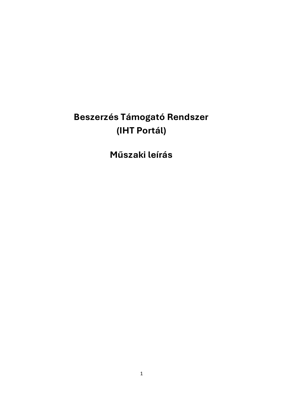

### Content (Page 1)

Beszerzés Támogató Rendszer
(IHT Portál)

Műszaki leírás

1


PAGE 2


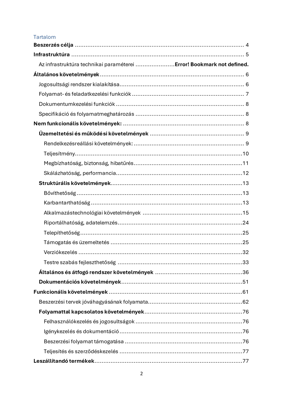

### Content (Page 2)

Tartalom
Beszerzés célja ........................................................................................................... 4
Infrastruktúra ............................................................................................................. 5
Az infrastruktúra technikai paraméterei ...................................................................... Error! Bookmark not defined.
Általános követelmények ........................................................................................... 6
Jogosultsági rendszer kialakítása .............................................................................. 6
Folyamat- és feladatkezelési funkciók ........................................................................ 7
Dokumentumkezelési funkciók ................................................................................... 8
Specifikáció és folyamatmeghatározás ....................................................................... 8
Nem funkcionális követelmények: ............................................................................. 8
Üzemeltetési és működési követelmények .................................................................. 9
Rendelkezésreállási követelmények: .......................................................................... 9
Teljesítmény ............................................................................................................. 10
Megbízhatóság, biztonság, hibatűrés ........................................................................ 11
Skálázhatóság, performance ..................................................................................... 12
Struktúrális követelmények ...................................................................................... 13
Bővíthetőség ........................................................................................................... 13
Karbantarthatóság ..................................................................................

*... (truncated)*


PAGE 3


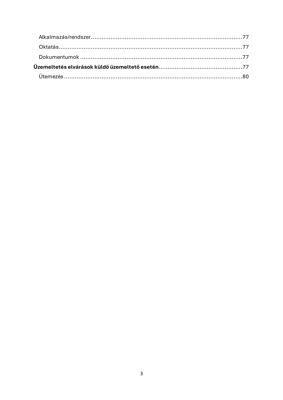

### Content (Page 3)

Alkalmazás/rendszer...........................................................................77
Oktatás.............................................................................................77
Dokumentumok .................................................................................77
Üzemeltetés elvárások küldő üzemeltető esetén...........................................77
Ütemezés...........................................................................................80

3


PAGE 4


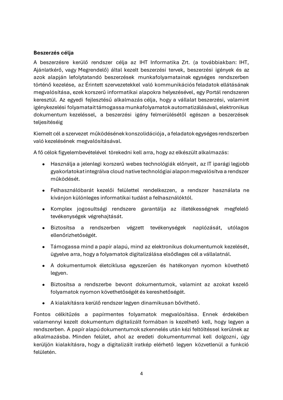

### Content (Page 4)

Beszerzés célja

A beszerzésre kerülő rendszer célja az IHT Informatika Zrt. (a továbbiakban: IHT, Ajánlatkérő, vagy Megrendelő) által kezelt beszerzési tervek, beszerzési igények és az azok alapján lefolytatandó beszerzések munkafolyamatainak egységes rendszerben történő kezelése, az Érintett szervezetekkel való kommunikációs feladatok ellátásának megvalósítása, ezek korszerű informatikai alapokra helyezésével, egy Portál rendszeren keresztül. Az egyedi fejlesztésű alkalmazás célja, hogy a vállalat beszerzési, valamint igénykezelési folyamatait támogassa munkafolyamatok automatizálásával, elektronikus dokumentum kezeléssel, a beszerzési igény felmerülésétől egészen a beszerzések teljesítéséig

Kiemelt cél a szervezet működésének konszolidációja, a feladatok egységes rendszerben való kezelésének megvalósításával.

A fő célok figyelembevételével törekedni kell arra, hogy az elkészült alkalmazás:

- Használja a jelenlegi korszerű webes technológiák előnyeit, az IT iparagi legjobb gyakorlatokat integrálva cloud native technológiai alapon megvalósítva a rendszer működését.
- Felhasználóbarát kezelői felülettel rendelkezzen, a rendszer használata ne kívánjon különleges informatikai tudást a felhasználóktól.
- Komplex jogosultsági rendszere garantálja az illetékességnek megfelelő tevékenységek végrehajtását.
- Biztosítsa a rendszerben végzett tevékenységek naplózását, utólagos ellenőrizhetőségét.
- Támogassa mind a papír alapú, mind az elektronikus dokumentumok kezelését, ügyelve arra, hogy a folyamatok digitalizálása elsődleges cél a vállalatnál.
- A dokumentumok életciklusa egyszerűen és hatékonyan nyomon követhető legyen.
- Biztosítsa a rendszerbe bevont dokumentumok, valamint az azokat kezelő folyamatok nyomon követhetőségét és kereshetőségét.
- A kialakításra kerülő rendszer legyen dinamikusan bővíthető.

Fontos célkitűzés a papírmentes folyamatok megvalósítása. Ennek érdekében valamennyi kezelt dokumentum digitalizált formában is kezelhető kell, hogy legyen a rendsz

*... (truncated)*


PAGE 5


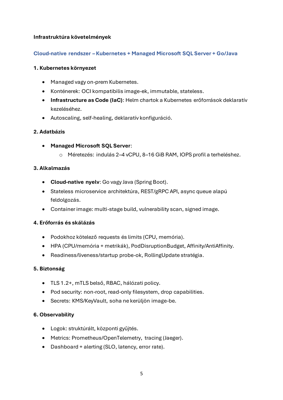

### Content (Page 5)

Infrastruktúra követelmények

Cloud-native rendszer – Kubernetes + Managed Microsoft SQL Server + Go/Java

1. Kubernetes környezet
    • Managed vagy on-prem Kubernetes.
    • Konténerek: OCI kompatibilis image-ek, immutable, stateless.
    • Infrastructure as Code (IaC): Helm chartok a Kubernetes erőforrások deklaratív kezeléséhez.
    • Autoscaling, self-healing, deklaratív konfiguráció.

2. Adatbázis
    • Managed Microsoft SQL Server:
        o Méretezés: indulás 2–4 vCPU, 8–16 GiB RAM, IOPS profil a terheléshez.

3. Alkalmazás
    • Cloud-native nyelv: Go vagy Java (Spring Boot).
    • Stateless microservice architektúra, REST/gRPC API, async queue alapú feldolgozás.
    • Container image: multi-stage build, vulnerability scan, signed image.

4. Erőforrás és skálázás
    • Podokhoz kötelező requests és limits (CPU, memória).
    • HPA (CPU/memória + metrikák), PodDisruptionBudget, Affinity/AntiAffinity.
    • Readiness/liveness/startup probe-ok, RollingUpdate stratégia.

5. Biztonság
    • TLS 1.2+, mTLS belső, RBAC, hálózati policy.
    • Pod security: non-root, read-only filesystem, drop capabilities.
    • Secrets: KMS/KeyVault, soha ne kerüljön image-be.

6. Observability
    • Logok: struktúrált, központi gyűjtés.
    • Metrics: Prometheus/OpenTelemetry, tracing (Jaeger).
    • Dashboard + alerting (SLO, latency, error rate).


... and 76 more pages (see exported JSON for full results)


In [17]:
# Display results per page (first 5 pages to avoid overwhelming output)
if Path(PDF_PATH).exists() and all_results:
    display_limit = min(5, len(all_results))
    for page_result in all_results[:display_limit]:
        pn = page_result["page_number"]
        print(f"\n{'=' * 60}")
        print(f"PAGE {pn}")
        print(f"{'=' * 60}")

        # Thumbnail
        thumb = page_result["full_page_image"].copy()
        thumb.thumbnail((400, 400))
        buf = io.BytesIO()
        thumb.save(buf, format="PNG")
        display(IPImage(data=buf.getvalue()))

        # Content (text + tables unified)
        display(Markdown(f"### Content (Page {pn})"))
        content_preview = page_result["content_markdown"][:2000]
        if len(page_result["content_markdown"]) > 2000:
            content_preview += "\n\n*... (truncated)*"
        display(Markdown(content_preview))

        # Figures
        if page_result["figures"]:
            display(Markdown(f"### Figures (Page {pn})"))
            for fig in page_result["figures"]:
                print(f"  Figure {fig.get('figure_id')}: {fig.get('description', '')[:200]}")
                if fig.get("saved_path") and Path(fig["saved_path"]).exists():
                    display(IPImage(filename=fig["saved_path"], width=400))

    if len(all_results) > display_limit:
        print(f"\n... and {len(all_results) - display_limit} more pages (see exported JSON for full results)")

## Process a DOCX Document

Same extraction pipeline as PDF, but with an extra conversion step at the front:

```
DOCX  ─▶  LibreOffice (headless)  ─▶  PDF  ─▶  pdf2image  ─▶  [page images]  ─▶  extract_pages_batch()
```

All intermediate files are preserved in the output subfolder:

```
extraction_output/<docx_stem>/
    <docx_stem>.pdf        # intermediate PDF from LibreOffice (preserved!)
    page_001.png           # rasterized page images
    page_002.png
    page1_fig1_crop.png    # cropped figures
    ...
```

Point `DOCX_PATH` at your file and run the cell.

**System requirement:** LibreOffice must be installed:
- Ubuntu/Debian: `sudo apt install libreoffice`
- macOS: `brew install --cask libreoffice`
- Windows: install from [libreoffice.org](https://www.libreoffice.org/) and ensure it is on your PATH

In [ ]:
# ── Configure your DOCX path here ───────────────────────────────
DOCX_PATH = "./test/test_docx.docx"  # <-- Change this to your DOCX

if Path(DOCX_PATH).exists():
    # Create a per-document output subfolder
    docx_stem = Path(DOCX_PATH).stem
    docx_output_dir = OUTPUT_DIR / docx_stem
    docx_output_dir.mkdir(parents=True, exist_ok=True)
    print(f"Output folder: {docx_output_dir}")

    # Convert DOCX to images, saving the intermediate PDF
    page_images = docx_to_images(DOCX_PATH, dpi=PDF_DPI, save_pdf_to=docx_output_dir)

    # Single batched call for ALL pages Ã— 2 prompts
    docx_results = extract_pages_batch(page_images, output_dir=docx_output_dir)

    # Post-process: crop detected figures
    for page_result in docx_results:
        crop_figures(page_result, output_dir=docx_output_dir)

    print(f"\n{'=' * 60}")
    print(f"DOCX Extraction Complete: {DOCX_PATH}")
    print(f"  Total pages: {len(docx_results)}")
    print(f"  Total figures found: {sum(len(r['figures']) for r in docx_results)}")
    print(f"\nAll files saved in: {docx_output_dir}")
    for f in sorted(docx_output_dir.iterdir()):
        print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")
else:
    print(f"DOCX not found: {DOCX_PATH}")
    print("Please update DOCX_PATH to point to a valid DOCX file.")
    print("Note: LibreOffice must be installed for DOCX conversion.")

Output folder: extraction_output/test_docx
Converting test_docx.docx to PDF via LibreOffice...
  -> PDF created: test_docx.pdf
  -> PDF saved to: extraction_output/test_docx/test_docx.pdf
Rasterizing test_docx.pdf at 200 DPI...
  -> 220 page(s) extracted
Encoded 220 page image(s) to base64
Processing 220 pages in 5 batch(es) of up to 50 pages (100 conversations each, 8 workers)

── Batch 1/5: pages 1-50 (50 pages, 100 conversations) ──


Extracting:   0%|          | 0/100 [00:00<?, ?it/s]

  Batch 1 done: 441,129 tokens, 121.0s wall time

── Batch 2/5: pages 51-100 (50 pages, 100 conversations) ──


Extracting:   0%|          | 0/100 [00:00<?, ?it/s]

  Batch 2 done: 445,420 tokens, 125.4s wall time

── Batch 3/5: pages 101-150 (50 pages, 100 conversations) ──


Extracting:   0%|          | 0/100 [00:00<?, ?it/s]

  Batch 3 done: 444,215 tokens, 136.2s wall time

── Batch 4/5: pages 151-200 (50 pages, 100 conversations) ──


Extracting:   0%|          | 0/100 [00:00<?, ?it/s]

  Batch 4 done: 435,972 tokens, 112.5s wall time

── Batch 5/5: pages 201-220 (20 pages, 40 conversations) ──


Extracting:   0%|          | 0/40 [00:00<?, ?it/s]

## Results Export

Two helper functions for saving and reviewing results:

- **`export_results()`** â€” serializes all per-page extraction results (content, figures,
  saved file paths) to a single JSON file inside the per-document output subfolder.
  PIL images are excluded from the JSON (they are already saved as separate PNG files).
- **`display_summary()`** â€” renders an HTML summary table showing per-page statistics
  (content length, figure count, errors, and the saved page image path).

After running all sections, the complete output folder structure looks like:

```
extraction_output/
    <image_stem>/
        page_001.png                  # copy of original image
        page1_fig1_crop.png           # figure crops
        <image_stem>_extraction.json  # JSON export
    <pdf_stem>/
        page_001.png                  # rasterized page images
        page_002.png
        page1_fig1_crop.png           # figure crops
        <pdf_stem>_extraction.json    # JSON export
    <docx_stem>/
        <docx_stem>.pdf               # intermediate PDF from LibreOffice
        page_001.png                  # rasterized page images
        page_002.png
        page1_fig1_crop.png           # figure crops
        <docx_stem>_extraction.json   # JSON export
```

Uncomment the lines in the cell after the function definitions to run the export.

In [ ]:
def export_results(
    results: list[dict],
    source_file: str,
    output_dir: Path | None = None,
) -> Path:
    """
    Export extraction results to a JSON file.
    PIL.Image objects are excluded (they are saved separately as page PNGs and figure crops).

    Args:
        results: List of per-page result dicts from extract_page().
        source_file: Original source filename (used to name the JSON file).
        output_dir: Directory to save the JSON file. Defaults to the per-document subfolder
                    or OUTPUT_DIR if not specified.
    """
    stem = Path(source_file).stem
    if output_dir is None:
        output_dir = OUTPUT_DIR / stem
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"{stem}_extraction.json"

    export_data = {
        "source_file": str(source_file),
        "total_pages": len(results),
        "pages": [],
    }

    for r in results:
        page_data = {
            "page_number": r["page_number"],
            "saved_page_path": r.get("saved_page_path"),
            "content_markdown": r["content_markdown"],
            "figures": [
                {k: v for k, v in fig.items() if k != "full_page_image"}
                for fig in r["figures"]
            ],
            "errors": r["errors"],
        }
        export_data["pages"].append(page_data)

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(export_data, f, indent=2, ensure_ascii=False)

    print(f"Results exported to: {output_path}")
    print(f"  Total pages: {export_data['total_pages']}")
    print(f"  File size: {output_path.stat().st_size / 1024:.1f} KB")

    return output_path


def display_summary(results: list[dict], source_name: str):
    """Display a summary table of extraction results."""
    rows = ""
    for r in results:
        saved = r.get("saved_page_path", "")
        rows += (
            f"<tr>"
            f"<td>{r['page_number']}</td>"
            f"<td>{len(r['content_markdown'])} chars</td>"
            f"<td>{len(r['figures'])}</td>"
            f"<td>{len(r['errors'])}</td>"
            f"<td>{saved or '-'}</td>"
            f"</tr>"
        )

    html = f"""
    <h3>Extraction Summary: {source_name}</h3>
    <table border="1" cellpadding="5" cellspacing="0" style="border-collapse: collapse;">
    <thead>
        <tr style="background-color: #f0f0f0;">
            <th>Page</th>
            <th>Content Length</th>
            <th>Figures</th>
            <th>Errors</th>
            <th>Saved Page Image</th>
        </tr>
    </thead>
    <tbody>{rows}</tbody>
    </table>
    """
    display(HTML(html))

In [ ]:
# Uncomment the lines below to export and display results.
# The JSON file is saved into the same per-document subfolder
# alongside the page images and figure crops.

# -- For single image results:
export_results([result], IMAGE_PATH, output_dir=img_output_dir)
display_summary([result], IMAGE_PATH)

# -- For PDF results:
export_results(all_results, PDF_PATH, output_dir=pdf_output_dir)
display_summary(all_results, PDF_PATH)

# -- For DOCX results:
export_results(docx_results, DOCX_PATH, output_dir=docx_output_dir)
display_summary(docx_results, DOCX_PATH)

## Evaluation & Observability

Use Opik's built-in metrics to validate extraction quality. The cells below demonstrate:

1. **JSON validation** — checks that figure extraction produces valid JSON (`IsJson` metric).
2. **Hallucination detection** — scores text extraction against ground truth context
   (`Hallucination` metric, requires a reference context).

After running extraction, open the Opik dashboard at `http://localhost:5173` to see:
- All traces with nested LLM spans (token counts, latency, model info)
- Registered prompts in the Prompt Library with version metadata
- Per-model token usage aggregates

In [ ]:
# ── Evaluation: validate extraction quality with Opik metrics ─────
from opik.evaluation.metrics import IsJson

json_metric = IsJson()

# Example: validate figure extraction output from a single-image run.
# Uncomment after running one of the extraction sections above.

# for fig in result.get("figures", []):
#     score = json_metric.score(output=json.dumps(fig))
#     print(f"  Figure {fig.get('figure_id')}: JSON valid = {score}")

# Example: validate all pages from a PDF run.
# for page_result in all_results:
#     for fig in page_result.get("figures", []):
#         score = json_metric.score(output=json.dumps(fig))
#         print(f"  Page {page_result['page_number']} fig {fig.get('figure_id')}: {score}")

# ── Hallucination detection (requires ground truth context) ───────
# from opik.evaluation.metrics import Hallucination
#
# hallucination_metric = Hallucination()
# score = hallucination_metric.score(
#     input="What does this document say about X?",
#     output=result["text_markdown"],
#     context=["Ground truth text here..."],
# )
# print(f"Hallucination score: {score}")

print("Evaluation metrics ready. Uncomment the examples above after running extraction.")

In [ ]:
# ── Flush Opik traces and close HTTP client ────────────────────
# Critical for notebooks: without flush(), pending spans may be lost
# because the background sender thread may not finish before the kernel stops.
opik_client.flush()

# Close the shared HTTP client (releases connection pool)
if "vllm_http_client" in dir() and vllm_http_client is not None:
    vllm_http_client.close()

# NOTE: Update this URL if you switch between Cloud and self-hosted Opik.
# Cloud:       https://www.comet.com/opik
# Self-hosted: http://localhost:5173
print("All Opik traces flushed. View results at https://www.comet.com/opik")